## Cell 1 - Note

In [18]:
# ============================================================
# 05_kde_infer_aggregate.ipynb
# Final inference + confidence weighting + session aggregation
# ============================================================
#
# Inputs:
#   - pred_query.npz
#   - hybrid_transfer_best.keras
#
# Outputs:
#   - per_window_predictions.csv
#   - per_session_aggregation.csv
#   - infer_summary.json
#
# Notes:
#   - geometry comes from hybrid model outputs
#   - amplitude metadata is used for confidence weighting
#   - first version uses exponential score weighting
#   - can be upgraded later to true KDE + JS divergence
# ============================================================

## Cell 2 - Import

In [19]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

## Cell 3 - Config

In [20]:
# ============================================================
# CONFIG
# ============================================================

DATA_ROOT = Path("/home/tonyliao/Location")   # change this
BUILD_DIR = DATA_ROOT / "dataset_build_hybrid"
TRANSFER_DIR = DATA_ROOT / "hybrid_train_runs"
OUT_DIR = DATA_ROOT / "hybrid_infer_runs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_QUERY_NPZ = BUILD_DIR / "pred_query.npz"
MODEL_PATH = TRANSFER_DIR / "hybrid_model_best.keras"
LABEL_MAP_JSON = BUILD_DIR / "label_map.json"

USE_AVECSI = False   # whether to use AveCSI features (requires re-building dataset with AveCSI)
TARGET_T = 256
TARGET_S = None

# confidence weighting
CONF_MODE = "presence_top1"   # "presence_top1", "exp_margin", or "uniform"
ALPHA_MARGIN = 4.0
MIN_WEIGHT = 1e-4

# aggregation
SESSION_KEY = "raw_folder_name"
USE_PRESENCE_FOR_WEIGHT = True
PRESENCE_POWER = 1.5

# empty gating
EMPTY_SESSION_THRESH = 0.20
EMPTY_WINDOW_THRESH = 0.15
USE_HARD_EMPTY_GATE = True

## Cell 4 - GPU Enable

In [21]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory growth warning:", e)

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 5 - Load Prediction

In [22]:
pred_query_obj = np.load(PRED_QUERY_NPZ, allow_pickle=True)
print("pred_query n =", len(pred_query_obj["label_id"]))

with open(LABEL_MAP_JSON, "r", encoding="utf-8") as f:
    label_meta = json.load(f)

label_map = label_meta["label_map"]
inv_label_map = {int(k): v for k, v in label_meta["inv_label_map"].items()}

NUM_CLASSES = len(label_map)
print("NUM_CLASSES =", NUM_CLASSES)
print(label_map)

pred_query n = 990
NUM_CLASSES = 9
{'Empty': 0, 'LeftDown': 1, 'LeftMid': 2, 'LeftUp': 3, 'MiddleDown': 4, 'MiddleUp': 5, 'RightDown': 6, 'RightMid': 7, 'RightUp': 8}


## Cell 6 - Helper

In [23]:
def np_load_float32(path):
    return np.load(str(path)).astype(np.float32)

def ensure_3d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x[..., None]
    return x

def resize_to_target(x, target_t, target_s):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    x_tf = tf.image.resize(x_tf, size=(target_t, target_s), method="bilinear")
    return x_tf.numpy().astype(np.float32)

def zscore_per_sample(x):
    mu = np.mean(x, axis=(0,1), keepdims=True)
    sd = np.std(x, axis=(0,1), keepdims=True) + 1e-6
    return ((x - mu) / sd).astype(np.float32)

def infer_target_s(npz_obj):
    a_amp = np_load_float32(npz_obj["A_amp_paths"][0])
    a_amp = ensure_3d(a_amp)
    return a_amp.shape[1]

if TARGET_S is None:
    TARGET_S = infer_target_s(pred_query_obj)

print("TARGET_T =", TARGET_T)
print("TARGET_S =", TARGET_S)

def build_amp_input_from_row(npz_obj, idx, use_avecsi=True):
    feats = []

    A = ensure_3d(np_load_float32(npz_obj["A_amp_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_amp_paths"][idx]))
    feats += [A, B]

    if use_avecsi:
        aavg_path = str(npz_obj["A_ampavg_paths"][idx])
        bavg_path = str(npz_obj["B_ampavg_paths"][idx])

        if aavg_path and bavg_path:
            Aavg = ensure_3d(np_load_float32(aavg_path))
            Bavg = ensure_3d(np_load_float32(bavg_path))

            Tref = A.shape[0]
            if Aavg.shape[0] == 1 and Tref > 1:
                Aavg = np.repeat(Aavg, Tref, axis=0)
            if Bavg.shape[0] == 1 and Tref > 1:
                Bavg = np.repeat(Bavg, Tref, axis=0)

            feats += [Aavg, Bavg]

    T0, S0 = feats[0].shape[:2]
    out = []
    for x in feats:
        if x.shape[0] != T0 or x.shape[1] != S0:
            x = resize_to_target(x, T0, S0)
        out.append(x)

    x = np.concatenate(out, axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

def build_phase_input_from_row(npz_obj, idx):
    A = ensure_3d(np_load_float32(npz_obj["A_pha_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_pha_paths"][idx]))

    T0 = max(A.shape[0], B.shape[0])
    S0 = max(A.shape[1], B.shape[1])

    if A.shape[:2] != (T0, S0):
        A = resize_to_target(A, T0, S0)
    if B.shape[:2] != (T0, S0):
        B = resize_to_target(B, T0, S0)

    x = np.concatenate([A, B], axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

CLASS_CENTER_MAP = {
    "Empty":       [0.0, 0.0],
    "LeftDown":    [2.0, 6.0],
    "LeftMid":     [2.0, 4.0],
    "LeftUp":      [2.0, 2.0],
    "MiddleDown":  [3.0, 6.0],
    "MiddleUp":    [3.0, 2.0],
    "RightDown":   [4.0, 6.0],
    "RightMid":    [4.0, 4.0],
    "RightUp":     [4.0, 2.0],
}

UNSEEN_GT_COORDS = {
    "LeftDown_Far": [0.0, 8.0],
    "LeftUp_Near": [2.0, 2.5],
    "LeftUp_Pred": [2.0, 2.0],
    "Corner": [6.0, 0.0],
    "Wall": [6.0, 5.0],
    "Center": [3.0, 4.0],
    # "Empty_Pred": [0.0, 0.0],
}

# def get_xy_from_label_name(label_name):
#     return np.asarray(CLASS_CENTER_MAP[str(label_name)], dtype=np.float32)

TARGET_T = 256
TARGET_S = 41


## Cell 7 - Load Model 

In [24]:
model = keras.models.load_model(
    MODEL_PATH,
    compile=False,
    safe_mode=False,
)

print("Loaded model:", MODEL_PATH)
model.summary()

Loaded model: /home/tonyliao/Location/hybrid_train_runs/hybrid_model_best.keras


Model: "hybrid_anchor_prob_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ amp_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_ssl_encoder     │ (None, 256)       │  1,307,008 │ amp_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_feat (Dense)    │ (None, 128)       │     32,896 │ amp_ssl_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pha_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phase_geometry_enc… │ (None, 128)       │  1,274,112 │ pha_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ presence_out        │ (None, 1)         │        129 │ amp_feat[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ amp_feat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 257)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
│                     │                   │            │ presence_out[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        130 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_delta_out       │ (None, 2)         │          0 │ dense_3[0][0]     │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_out (Dense)   │ (None, 9)         │      1,161 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_gate (Dense)  │ (None, 1)         │         33 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aoa_xy_out (Dense)  │ (None, 2)         │         18 │ class_out[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2)         │          0 │ amp_delta_out[0]… │
│                     │                   │            │ delta_gate[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_xy_out (Add)  │ (None, 2)         │          0 │ aoa_xy_out[0][0], │
│                     │                   │            │ multiply[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,664,895 (10.17 MB)

 Trainable params: 1,487,533 (5.67 MB)

 Non-trainable params: 1,177,362 (4.49 MB)

## Cell 8 - Prediction Helper

In [25]:
def softmax_margin(prob):
    prob = np.asarray(prob, dtype=np.float32).reshape(-1)
    if len(prob) < 2:
        return 0.0
    top2 = np.sort(prob)[-2:]
    return float(top2[-1] - top2[-2])

def get_scalar_meta(npz_obj, key, idx, default=np.nan):
    if key in npz_obj.files:
        return float(npz_obj[key][idx])
    return default

def compute_confidence_weight(npz_obj, idx, pred_dict):
    presence = float(pred_dict["presence"])
    class_prob = np.asarray(pred_dict["class_prob"], dtype=np.float32)
    top1 = float(np.max(class_prob))
    margin = softmax_margin(class_prob)

    if CONF_MODE == "presence_top1":
        w = (max(presence, 1e-3) ** PRESENCE_POWER) * max(top1, 1e-3)

    elif CONF_MODE == "exp_margin":
        w = math.exp(ALPHA_MARGIN * margin)
        if USE_PRESENCE_FOR_WEIGHT:
            w *= max(presence, 1e-3) ** PRESENCE_POWER

    else:
        w = 1.0
        if USE_PRESENCE_FOR_WEIGHT:
            w *= max(presence, 1e-3) ** PRESENCE_POWER

    return max(float(w), MIN_WEIGHT)

def predict_one(npz_obj, idx, model):
    amp = build_amp_input_from_row(npz_obj, idx, use_avecsi=USE_AVECSI)
    pha = build_phase_input_from_row(npz_obj, idx)

    x = {
        "amp_in": np.expand_dims(amp, axis=0),
        "pha_in": np.expand_dims(pha, axis=0),
    }

    pred = model.predict(x, verbose=0)

    class_prob = pred["class_out"][0].astype(np.float32)
    class_id = int(np.argmax(class_prob))

    out = {
        "presence": float(pred["presence_out"][0, 0]),
        "class_prob": class_prob,
        "class_id": class_id,
        "class_name": inv_label_map[class_id],
        "top1_prob": float(np.max(class_prob)),
        "top2_margin": float(softmax_margin(class_prob)),
        "aoa_xy": pred["aoa_xy_out"][0].astype(np.float32),
        "amp_delta": pred["amp_delta_out"][0].astype(np.float32),
        "final_xy": pred["final_xy_out"][0].astype(np.float32),
    }
    return out

example = predict_one(pred_query_obj, 0, model)
for k, v in example.items():
    print(k, v)

I0000 00:00:1775569518.447906 3671596 service.cc:152] XLA service 0x7fb1f8019db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775569518.447919 3671596 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-07 13:45:18.454863: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775569518.547127 3671596 cuda_dnn.cc:529] Loaded cuDNN version 90300


presence 0.934596598148346
class_prob [0.0019166  0.6547113  0.07499035 0.03136556 0.09636708 0.01200326
 0.01111969 0.04605703 0.07146917]
class_id 1
class_name LeftDown
top1_prob 0.6547113060951233
top2_margin 0.5583442449569702
aoa_xy [2.361829 5.287054]
amp_delta [ 0.3030486  -0.01951944]
final_xy [2.3672245 5.2867064]


I0000 00:00:1775569519.187204 3671596 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## Cell 9 - Per-Window Prediction + Confidence Weighting

In [26]:
rows = []
n = len(pred_query_obj["label_id"])

for i in range(n):
    pred = predict_one(pred_query_obj, i, model)
    w = compute_confidence_weight(pred_query_obj, i, pred)

    raw_folder_name = str(pred_query_obj["raw_folder_name"][i]) if "raw_folder_name" in pred_query_obj.files else "Unknown"
    loc_dir = str(pred_query_obj["loc_dir"][i]) if "loc_dir" in pred_query_obj.files else ""
    pair_id = str(pred_query_obj["pair_id"][i]) if "pair_id" in pred_query_obj.files else str(i)

    pred_xy = np.asarray(pred["final_xy"], dtype=np.float32)
    aoa_xy = np.asarray(pred["aoa_xy"], dtype=np.float32)
    amp_delta = np.asarray(pred["amp_delta"], dtype=np.float32)

    has_gt = raw_folder_name in UNSEEN_GT_COORDS
    if has_gt:
        true_xy = np.asarray(UNSEEN_GT_COORDS[raw_folder_name], dtype=np.float32)
        err_final = float(np.linalg.norm(true_xy - pred_xy))
        err_aoa = float(np.linalg.norm(true_xy - aoa_xy))
        true_x = float(true_xy[0])
        true_y = float(true_xy[1])
    else:
        true_x = np.nan
        true_y = np.nan
        err_final = np.nan
        err_aoa = np.nan

    rows.append({
        "idx": i,
        "domain": str(pred_query_obj["domain"][i]) if "domain" in pred_query_obj.files else "pred",
        "raw_folder_name": raw_folder_name,
        "loc_dir": loc_dir,
        "pair_id": pair_id,

        "has_gt": int(has_gt),
        "true_x": true_x,
        "true_y": true_y,

        "presence": float(pred["presence"]),
        "pred_empty_window": int(float(pred["presence"]) < EMPTY_WINDOW_THRESH),
        "weight": float(w),

        "pred_label_id": int(pred["class_id"]),
        "pred_label_name": str(pred["class_name"]),
        "top1_prob": float(pred["top1_prob"]),
        "top2_margin": float(pred["top2_margin"]),

        "aoa_x": float(aoa_xy[0]),
        "aoa_y": float(aoa_xy[1]),

        "delta_x": float(amp_delta[0]),
        "delta_y": float(amp_delta[1]),

        "final_x": float(pred_xy[0]),
        "final_y": float(pred_xy[1]),

        "err_aoa": err_aoa,
        "err_final": err_final,

        "A_win_score": get_scalar_meta(pred_query_obj, "A_win_score", i, default=np.nan),
        "B_win_score": get_scalar_meta(pred_query_obj, "B_win_score", i, default=np.nan),
        "A_amp_std": get_scalar_meta(pred_query_obj, "A_amp_std", i, default=np.nan),
        "B_amp_std": get_scalar_meta(pred_query_obj, "B_amp_std", i, default=np.nan),
    })

df_win = pd.DataFrame(rows)
print(df_win.shape)
display(df_win.head())

(990, 27)


,idx,domain,raw_folder_name,loc_dir,pair_id,has_gt,true_x,true_y,presence,pred_empty_window,...,delta_x,delta_y,final_x,final_y,err_aoa,err_final,A_win_score,B_win_score,A_amp_std,B_amp_std
0,0,pred,Wall,/home/tonyliao/Location/Pred/Wall,00136,1,6.0,5.0,0.934597,0,...,0.303049,-0.019519,2.367224,5.286706,3.649478,3.644072,0.587636,0.621729,8.889204,3.970613
1,1,pred,Wall,/home/tonyliao/Location/Pred/Wall,00079,1,6.0,5.0,0.926214,0,...,-0.586860,0.500278,2.657011,4.679041,3.262033,3.358361,0.634761,0.739558,6.085402,5.713139
2,2,pred,Wall,/home/tonyliao/Location/Pred/Wall,00125,1,6.0,5.0,0.985311,0,...,-0.118392,0.458984,2.985324,4.248950,3.106849,3.106822,0.613076,0.677978,8.313828,4.195358
3,3,pred,LeftUp_Near,/home/tonyliao/Location/Pred/LeftUp_Near,00135,1,2.0,2.5,0.999942,0,...,-0.639209,-0.429860,2.017480,5.950989,3.451533,3.451033,0.600598,0.654405,3.575358,7.683388
4,4,pred,Wall,/home/tonyliao/Location/Pred/Wall,00101,1,6.0,5.0,0.947802,0,...,-0.294705,0.276180,3.186635,4.023373,2.951784,2.978057,0.587648,0.652802,9.404760,4.278083


## Cell 10 - Session Aggregation Helper

In [27]:
# session-level aggregation

def weighted_xy(group_df):
    w = group_df["weight"].values.astype(np.float64)
    x = group_df["final_x"].values.astype(np.float64)
    y = group_df["final_y"].values.astype(np.float64)

    ws = np.sum(w)
    if ws <= 0:
        return float(np.mean(x)), float(np.mean(y))
    return float(np.sum(w * x) / ws), float(np.sum(w * y) / ws)

def unweighted_xy(group_df):
    return float(group_df["final_x"].mean()), float(group_df["final_y"].mean())

def majority_vote_label(group_df):
    return group_df["pred_label_name"].value_counts().idxmax()

ANCHOR_NAMES = [k for k in CLASS_CENTER_MAP.keys() if k != "Empty"]
ANCHOR_XY = np.asarray([CLASS_CENTER_MAP[k] for k in ANCHOR_NAMES], dtype=np.float32)

def snap_to_nearest_anchor(xy):
    xy = np.asarray(xy, dtype=np.float32).reshape(1, 2)
    d = np.linalg.norm(ANCHOR_XY - xy, axis=1)
    idx = int(np.argmin(d))
    return ANCHOR_NAMES[idx], ANCHOR_XY[idx].copy(), float(d[idx])

def nearest_anchor_of_gt(true_xy):
    return snap_to_nearest_anchor(true_xy)[0]

## Cell 11 - Aggregation Weighting

In [28]:
session_rows = []

for key, g in df_win.groupby(SESSION_KEY):
    raw_folder_name = g["raw_folder_name"].mode().iloc[0]
    has_gt = raw_folder_name in UNSEEN_GT_COORDS

    mean_presence = float(g["presence"].mean()) if "presence" in g.columns else np.nan
    gt_empty = "Yes" if str(raw_folder_name).lower().startswith("empty") else "No"
    pred_empty = "Yes" if (np.isfinite(mean_presence) and mean_presence < EMPTY_SESSION_THRESH) else "No"

    if USE_HARD_EMPTY_GATE and pred_empty == "Yes":
        ux, uy = np.nan, np.nan
        wx, wy = np.nan, np.nan

        snap_name_unweighted = "Empty"
        snap_name_weighted = "Empty"

        snap_xy_unweighted = np.array([np.nan, np.nan], dtype=np.float32)
        snap_xy_weighted = np.array([np.nan, np.nan], dtype=np.float32)

        move_unweighted = np.nan
        move_weighted = np.nan

        pred_label_majority = "Empty"

        if has_gt:
            true_xy = np.asarray(UNSEEN_GT_COORDS[raw_folder_name], dtype=np.float32)
            true_x = float(true_xy[0])
            true_y = float(true_xy[1])
        else:
            true_x = np.nan
            true_y = np.nan

        err_unweighted = np.nan
        err_weighted = np.nan
        err_unweighted_snap = np.nan
        err_weighted_snap = np.nan

        gt_anchor_name = "Empty" if gt_empty == "Yes" else ""
        snapped_correct_unweighted = int(gt_empty == "Yes")
        snapped_correct_weighted = int(gt_empty == "Yes")

        mean_final_x = np.nan
        mean_final_y = np.nan
        std_final_x = np.nan
        std_final_y = np.nan

    else:
        ux, uy = unweighted_xy(g)
        wx, wy = weighted_xy(g)

        pred_unweighted_xy = np.array([ux, uy], dtype=np.float32)
        pred_weighted_xy = np.array([wx, wy], dtype=np.float32)

        snap_name_unweighted, snap_xy_unweighted, move_unweighted = snap_to_nearest_anchor(pred_unweighted_xy)
        snap_name_weighted, snap_xy_weighted, move_weighted = snap_to_nearest_anchor(pred_weighted_xy)

        pred_label_majority = majority_vote_label(g)

        if has_gt:
            true_xy = np.asarray(UNSEEN_GT_COORDS[raw_folder_name], dtype=np.float32)
            err_unweighted = float(np.linalg.norm(true_xy - pred_unweighted_xy))
            err_weighted = float(np.linalg.norm(true_xy - pred_weighted_xy))

            err_unweighted_snap = float(np.linalg.norm(true_xy - snap_xy_unweighted))
            err_weighted_snap = float(np.linalg.norm(true_xy - snap_xy_weighted))

            gt_anchor_name = nearest_anchor_of_gt(true_xy)
            snapped_correct_unweighted = int(snap_name_unweighted == gt_anchor_name)
            snapped_correct_weighted = int(snap_name_weighted == gt_anchor_name)

            true_x = float(true_xy[0])
            true_y = float(true_xy[1])
        else:
            err_unweighted = np.nan
            err_weighted = np.nan
            err_unweighted_snap = np.nan
            err_weighted_snap = np.nan
            gt_anchor_name = ""
            snapped_correct_unweighted = np.nan
            snapped_correct_weighted = np.nan
            true_x = np.nan
            true_y = np.nan

        mean_final_x = float(g["final_x"].mean())
        mean_final_y = float(g["final_y"].mean())
        std_final_x = float(g["final_x"].std(ddof=0))
        std_final_y = float(g["final_y"].std(ddof=0))

    session_rows.append({
        SESSION_KEY: key,
        "raw_folder_name": raw_folder_name,
        "n_windows": int(len(g)),

        "GT Empty": gt_empty,
        "Pred Empty": pred_empty,

        "has_gt": int(has_gt),
        "true_x": true_x,
        "true_y": true_y,

        "unweighted_x": ux,
        "unweighted_y": uy,
        "weighted_x": wx,
        "weighted_y": wy,

        "snap_unweighted_label": snap_name_unweighted,
        "snap_unweighted_x": float(snap_xy_unweighted[0]) if np.isfinite(snap_xy_unweighted[0]) else np.nan,
        "snap_unweighted_y": float(snap_xy_unweighted[1]) if np.isfinite(snap_xy_unweighted[1]) else np.nan,

        "snap_weighted_label": snap_name_weighted,
        "snap_weighted_x": float(snap_xy_weighted[0]) if np.isfinite(snap_xy_weighted[0]) else np.nan,
        "snap_weighted_y": float(snap_xy_weighted[1]) if np.isfinite(snap_xy_weighted[1]) else np.nan,

        "gt_nearest_anchor": gt_anchor_name,
        "pred_label_majority": pred_label_majority,

        "err_unweighted": err_unweighted,
        "err_weighted": err_weighted,
        "err_unweighted_snap": err_unweighted_snap,
        "err_weighted_snap": err_weighted_snap,

        "snap_move_unweighted": move_unweighted,
        "snap_move_weighted": move_weighted,
        "snap_correct_unweighted": snapped_correct_unweighted,
        "snap_correct_weighted": snapped_correct_weighted,

        "mean_presence": mean_presence,
        "mean_weight": float(g["weight"].mean()),
        "mean_final_x": mean_final_x,
        "mean_final_y": mean_final_y,
        "std_final_x": std_final_x,
        "std_final_y": std_final_y,
    })

df_sess = pd.DataFrame(session_rows)
print(df_sess.shape)
display(df_sess.head())

(7, 33)


,raw_folder_name,n_windows,GT Empty,Pred Empty,has_gt,true_x,true_y,unweighted_x,unweighted_y,weighted_x,...,snap_move_unweighted,snap_move_weighted,snap_correct_unweighted,snap_correct_weighted,mean_presence,mean_weight,mean_final_x,mean_final_y,std_final_x,std_final_y
0,Center,145,No,No,1,3.0,4.0,2.444290,5.410512,2.347827,...,0.738166,0.581724,0.0,0.0,0.983058,0.694507,2.444290,5.410512,0.577727,0.497596
1,Corner,135,No,No,1,6.0,0.0,2.706238,5.268166,2.716316,...,0.788592,0.644498,0.0,0.0,0.975323,0.587402,2.706238,5.268166,0.553760,0.474885
2,Empty_Pred,145,Yes,No,0,NaN,NaN,3.163417,4.307202,3.215503,...,0.891204,0.800834,NaN,NaN,0.990908,0.509895,3.163417,4.307202,0.576285,0.935587
3,LeftDown_Far,142,No,No,1,0.0,8.0,2.522892,5.214206,2.473705,...,0.919295,0.833997,0.0,1.0,0.912920,0.588924,2.522892,5.214206,0.526806,0.610606
4,LeftUp_Near,139,No,No,1,2.0,2.5,2.587032,5.064314,2.474382,...,1.022766,0.870044,0.0,0.0,0.998811,0.588807,2.587032,5.064314,0.432999,0.797481


## Cell 13 - Summary

In [29]:
window_cls_counts = df_win["pred_label_name"].value_counts().to_dict()

summary = {
    "n_windows": int(len(df_win)),
    "n_sessions": int(len(df_sess)),
    "conf_mode": CONF_MODE,
    # "alpha_score": ALPHA_SCORE,
    "alpha_margin": ALPHA_MARGIN,
    "use_presence_for_weight": USE_PRESENCE_FOR_WEIGHT,
    "presence_power": PRESENCE_POWER,
    "predicted_label_counts": window_cls_counts,
}

# only compute error summary if GT exists for some sessions
df_win_gt = df_win[df_win["has_gt"] == 1].copy()
df_sess_gt = df_sess[df_sess["has_gt"] == 1].copy()

if len(df_win_gt) > 0:
    summary["window_mean_err_final"] = float(df_win_gt["err_final"].mean())
    summary["window_median_err_final"] = float(df_win_gt["err_final"].median())

if len(df_sess_gt) > 0:
    summary["session_mean_err_unweighted"] = float(df_sess_gt["err_unweighted"].mean())
    summary["session_median_err_unweighted"] = float(df_sess_gt["err_unweighted"].median())
    summary["session_mean_err_weighted"] = float(df_sess_gt["err_weighted"].mean())
    summary["session_median_err_weighted"] = float(df_sess_gt["err_weighted"].median())

    summary["session_mean_err_unweighted_snap"] = float(df_sess_gt["err_unweighted_snap"].mean())
    summary["session_median_err_unweighted_snap"] = float(df_sess_gt["err_unweighted_snap"].median())
    summary["session_mean_err_weighted_snap"] = float(df_sess_gt["err_weighted_snap"].mean())
    summary["session_median_err_weighted_snap"] = float(df_sess_gt["err_weighted_snap"].median())

    summary["session_snap_anchor_acc_unweighted"] = float(df_sess_gt["snap_correct_unweighted"].mean())
    summary["session_snap_anchor_acc_weighted"] = float(df_sess_gt["snap_correct_weighted"].mean())

print(json.dumps(summary, indent=2))


{
  "n_windows": 990,
  "n_sessions": 7,
  "conf_mode": "presence_top1",
  "alpha_margin": 4.0,
  "use_presence_for_weight": true,
  "presence_power": 1.5,
  "predicted_label_counts": {
    "LeftDown": 628,
    "RightDown": 144,
    "RightMid": 78,
    "RightUp": 78,
    "MiddleUp": 51,
    "MiddleDown": 5,
    "LeftMid": 5,
    "Empty": 1
  },
  "window_mean_err_final": 3.384302654597886,
  "window_median_err_final": 3.1724202632904053,
  "session_mean_err_unweighted": 3.3616087635358176,
  "session_median_err_unweighted": 3.02573823928833,
  "session_mean_err_weighted": 3.4609785874684653,
  "session_median_err_weighted": 3.149105191230774,
  "session_mean_err_unweighted_snap": 3.85690176486969,
  "session_median_err_unweighted_snap": 3.6228030920028687,
  "session_mean_err_weighted_snap": 3.7040385802586875,
  "session_median_err_weighted_snap": 3.164213538169861,
  "session_snap_anchor_acc_unweighted": 0.0,
  "session_snap_anchor_acc_weighted": 0.16666666666666666
}


## Cell 14 - Result

In [30]:
print("Inference summary")
print("  n_windows :", len(df_win))
print("  n_sessions:", len(df_sess))

# empty / non-empty
if {"GT Empty", "Pred Empty"}.issubset(df_sess.columns):
    y_true_empty = (df_sess["GT Empty"] == "Yes").astype(int).values
    y_pred_empty = (df_sess["Pred Empty"] == "Yes").astype(int).values

    tp = int(((y_true_empty == 1) & (y_pred_empty == 1)).sum())
    tn = int(((y_true_empty == 0) & (y_pred_empty == 0)).sum())
    fp = int(((y_true_empty == 0) & (y_pred_empty == 1)).sum())
    fn = int(((y_true_empty == 1) & (y_pred_empty == 0)).sum())

    acc_empty = (tp + tn) / max(len(y_true_empty), 1)
    prec_empty = tp / max(tp + fp, 1)
    rec_empty = tp / max(tp + fn, 1)
    f1_empty = 2 * prec_empty * rec_empty / max(prec_empty + rec_empty, 1e-8)

    print("\nEmpty / Non-empty metrics")
    print(f"  TP={tp}, TN={tn}, FP={fp}, FN={fn}")
    print(f"  Accuracy : {acc_empty:.3f}")
    print(f"  Precision: {prec_empty:.3f}")
    print(f"  Recall   : {rec_empty:.3f}")
    print(f"  F1       : {f1_empty:.3f}")

# localization metrics only on GT non-empty + predicted non-empty
mask_loc = (
    (df_sess["has_gt"] == 1) &
    (df_sess["GT Empty"] == "No") &
    (df_sess["Pred Empty"] == "No")
)

df_loc = df_sess.loc[mask_loc].copy()

if len(df_loc) > 0:
    print("\nGT-available non-empty session metrics (continuous)")
    print("  weighted mean     :", float(df_loc["err_weighted"].mean()))
    print("  weighted median   :", float(df_loc["err_weighted"].median()))

    print("\nGT-available non-empty session metrics (nearest-anchor snapped)")
    print("  weighted mean     :", float(df_loc["err_weighted_snap"].mean()))
    print("  weighted median   :", float(df_loc["err_weighted_snap"].median()))
    print("  snap anchor acc w :", float(df_loc["snap_correct_weighted"].mean()))

print("\nPredicted label counts")
print(df_sess["pred_label_majority"].value_counts(dropna=False).to_dict())

compare_df = df_sess[[
    "raw_folder_name",
    "n_windows",
    "GT Empty",
    "Pred Empty",
    "pred_label_majority",
    "gt_nearest_anchor",
    "snap_weighted_label",
    "err_weighted",
    "err_weighted_snap",
    "snap_correct_unweighted",
    "snap_correct_weighted",
]].copy()

compare_df = compare_df.sort_values("raw_folder_name").reset_index(drop=True)
display(compare_df)

Inference summary
  n_windows : 990
  n_sessions: 7

Empty / Non-empty metrics
  TP=0, TN=6, FP=0, FN=1
  Accuracy : 0.857
  Precision: 0.000
  Recall   : 0.000
  F1       : 0.000

GT-available non-empty session metrics (continuous)
  weighted mean     : 3.4609785874684653
  weighted median   : 3.149105191230774

GT-available non-empty session metrics (nearest-anchor snapped)
  weighted mean     : 3.7040385802586875
  weighted median   : 3.164213538169861
  snap anchor acc w : 0.16666666666666666

Predicted label counts
{'LeftDown': 6, 'RightDown': 1}


,raw_folder_name,n_windows,GT Empty,Pred Empty,pred_label_majority,gt_nearest_anchor,snap_weighted_label,err_weighted,err_weighted_snap,snap_correct_unweighted,snap_correct_weighted
0,Center,145,No,No,LeftDown,LeftMid,LeftDown,1.666619,2.236068,0.0,0.0
1,Corner,135,No,No,LeftDown,RightUp,MiddleDown,6.338217,6.708204,0.0,0.0
2,Empty_Pred,145,Yes,No,LeftDown,,RightMid,NaN,NaN,NaN,NaN
3,LeftDown_Far,142,No,No,LeftDown,LeftDown,LeftDown,3.651849,2.828427,0.0,1.0
4,LeftUp_Near,139,No,No,LeftDown,LeftUp,LeftDown,2.810976,3.500000,0.0,0.0
5,LeftUp_Pred,144,No,No,RightDown,LeftUp,RightMid,2.993340,2.828427,0.0,0.0
6,Wall,140,No,No,LeftDown,RightDown,LeftMid,3.304870,4.123106,0.0,0.0


## Cell 15 - Plot

,Session,GT Empty,Pred Empty,GT Nearest,Pred Anchor,Anchor Correct
0,Center,No,No,LeftMid,LeftDown,No
1,Corner,No,No,RightUp,MiddleDown,No
2,Empty_Pred,Yes,No,,RightMid,NaN
3,LeftDown_Far,No,No,LeftDown,LeftDown,Yes
4,LeftUp_Near,No,No,LeftUp,LeftDown,No
5,LeftUp_Pred,No,No,LeftUp,RightMid,No
6,Wall,No,No,RightDown,LeftMid,No


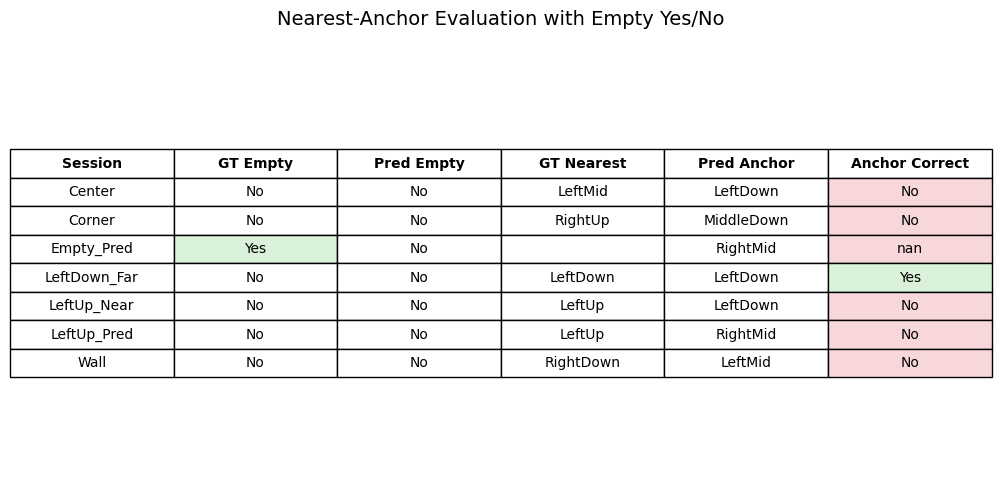

Saved: /home/tonyliao/Location/hybrid_infer_runs/nearest_anchor_empty_yesno_table.png


In [31]:
# ============================================
# PLOT-TABLE: GT Nearest / Pred Anchor / Anchor Correct
# ============================================
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_sess[[
    "raw_folder_name",
    "GT Empty",
    "Pred Empty",
    "gt_nearest_anchor",
    "snap_weighted_label",
    "snap_correct_weighted"
]].copy()

df_plot = df_plot.rename(columns={
    "raw_folder_name": "Session",
    "gt_nearest_anchor": "GT Nearest",
    "snap_weighted_label": "Pred Anchor",
    "snap_correct_weighted": "Anchor Correct"
})

df_plot["Anchor Correct"] = df_plot["Anchor Correct"].map({1: "Yes", 0: "No"})
df_plot = df_plot.sort_values("Session").reset_index(drop=True)

display(df_plot)

n_rows = len(df_plot)
fig_h = max(2.8, 0.55 * n_rows + 1.2)

fig, ax = plt.subplots(figsize=(10, fig_h))
ax.axis("off")

table = ax.table(
    cellText=df_plot.values,
    colLabels=df_plot.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.5)

for j in range(len(df_plot.columns)):
    table[0, j].set_text_props(weight="bold")

gt_empty_idx = list(df_plot.columns).index("GT Empty")
pred_empty_idx = list(df_plot.columns).index("Pred Empty")
correct_idx = list(df_plot.columns).index("Anchor Correct")

for i in range(1, n_rows + 1):
    if df_plot.iloc[i - 1, gt_empty_idx] == "Yes":
        table[i, gt_empty_idx].set_facecolor("#d9f2d9")
    if df_plot.iloc[i - 1, pred_empty_idx] == "Yes":
        table[i, pred_empty_idx].set_facecolor("#d9f2d9")
    if df_plot.iloc[i - 1, correct_idx] == "Yes":
        table[i, correct_idx].set_facecolor("#d9f2d9")
    else:
        table[i, correct_idx].set_facecolor("#f8d7da")

ax.set_title("Nearest-Anchor Evaluation with Empty Yes/No", fontsize=14, pad=12)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "nearest_anchor_empty_yesno_table.png")
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

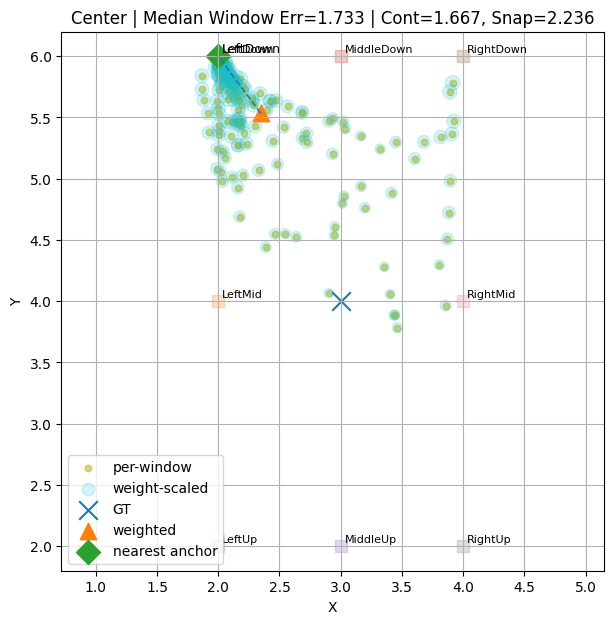

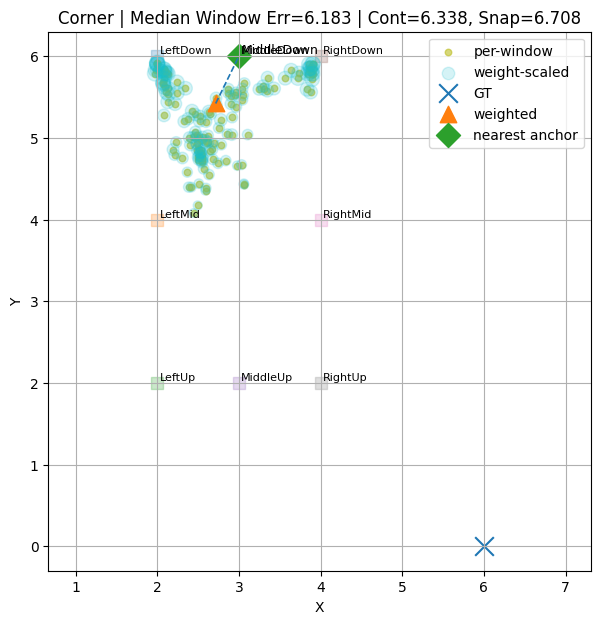

/home/tonyliao/tensorflow_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


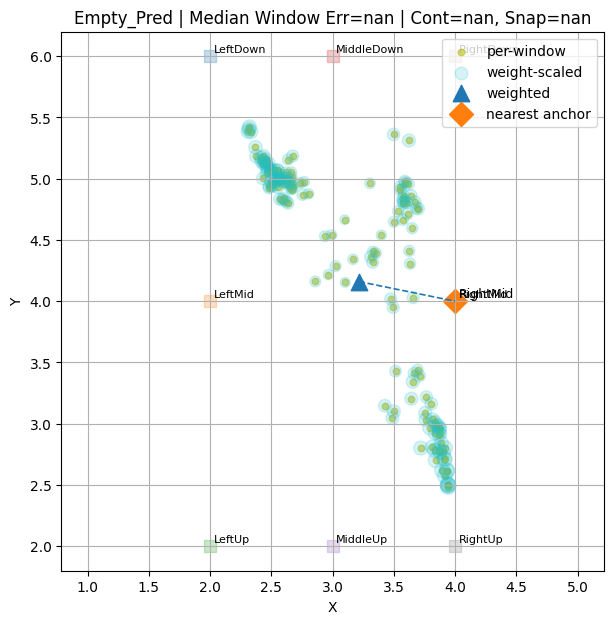

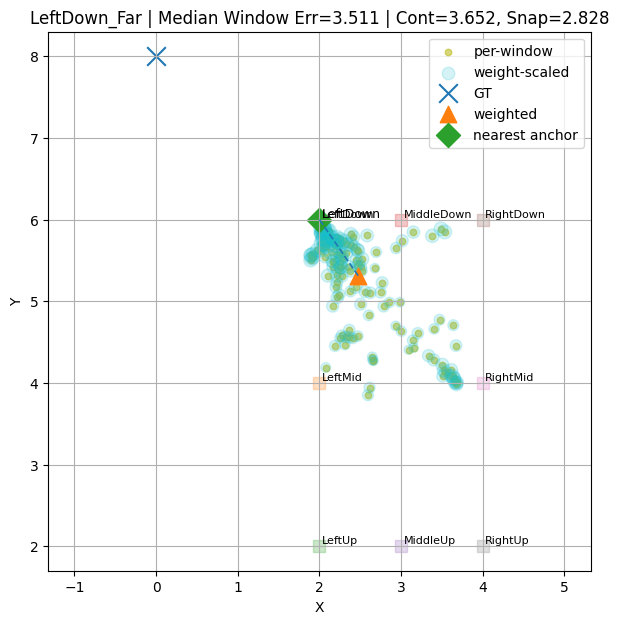

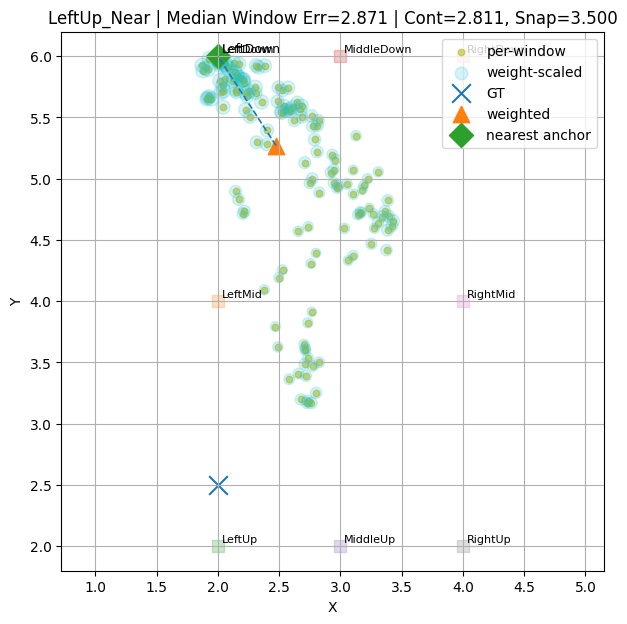

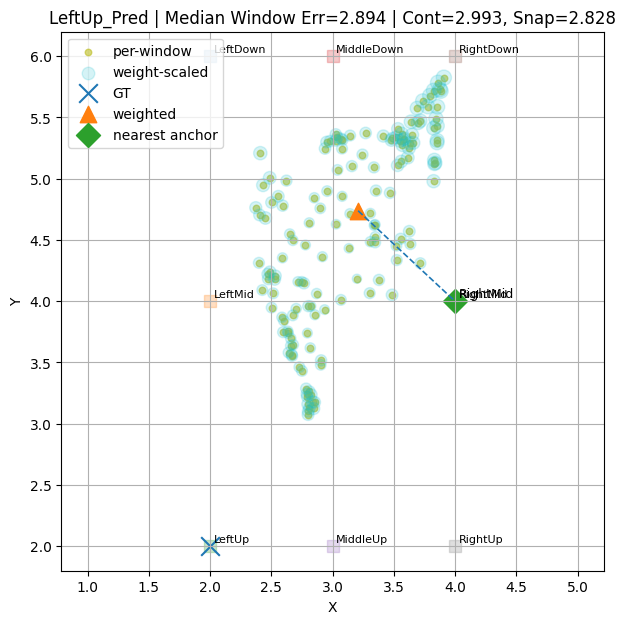

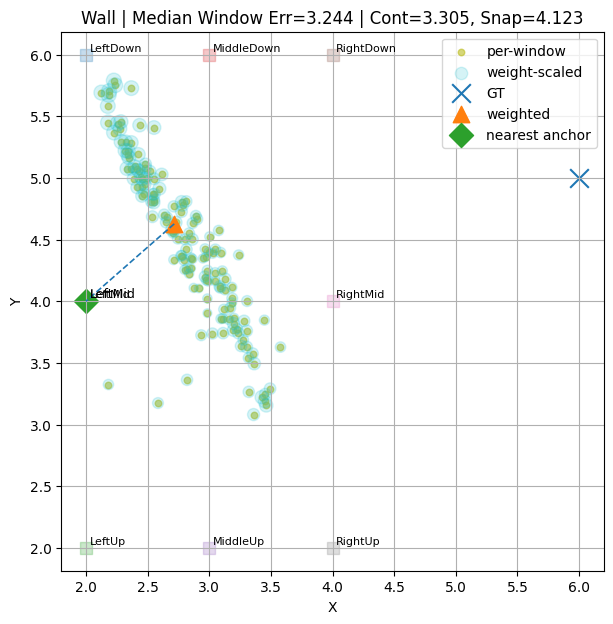

In [32]:
FIG_DIR = OUT_DIR / "nearest_anchor_plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)
for session_name in sorted(df_sess["raw_folder_name"].unique()):
    g = df_win[df_win["raw_folder_name"] == session_name].copy()
    if len(g) == 0:
        continue

    sess = df_sess[df_sess["raw_folder_name"] == session_name].iloc[0]
    has_gt = bool(sess["has_gt"])

    plt.figure(figsize=(7, 7))

    # anchor centers
    for anchor_name, anchor_xy in CLASS_CENTER_MAP.items():
        if anchor_name == "Empty":
            continue
        anchor_xy = np.asarray(anchor_xy, dtype=np.float32)
        plt.scatter(anchor_xy[0], anchor_xy[1], marker="s", s=70, alpha=0.25)
        plt.text(anchor_xy[0] + 0.03, anchor_xy[1] + 0.03, anchor_name, fontsize=8)

    # per-window predictions
    plt.scatter(g["final_x"], g["final_y"], s=22, alpha=0.6, label="per-window")

    # weight-scaled view
    if "weight" in g.columns and len(g) > 0:
        w_norm = g["weight"] / max(float(g["weight"].max()), 1e-8)
        plt.scatter(
            g["final_x"],
            g["final_y"],
            s=20 + 100 * w_norm,
            alpha=0.18,
            label="weight-scaled"
        )

    # GT
    if has_gt and np.isfinite(sess["true_x"]) and np.isfinite(sess["true_y"]):
        plt.scatter(sess["true_x"], sess["true_y"], marker="x", s=180, label="GT")

    # if predicted empty, do NOT draw weighted/snap localization
    if sess["Pred Empty"] == "Yes":
        title = f"{session_name} | Pred Empty | mean_presence={sess['mean_presence']:.3f}"
        if sess["GT Empty"] == "Yes":
            title += " | GT Empty"
        else:
            title += f" | GT Non-Empty"
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(title)
        plt.grid(True)
        plt.axis("equal")
        plt.legend()
        plt.show()
        continue

    # weighted continuous prediction
    plt.scatter(sess["weighted_x"], sess["weighted_y"], s=140, marker="^", label="weighted")

    # snapped nearest anchor
    plt.scatter(sess["snap_weighted_x"], sess["snap_weighted_y"], s=150, marker="D", label="nearest anchor")

    # line from weighted to snapped
    plt.plot(
        [sess["weighted_x"], sess["snap_weighted_x"]],
        [sess["weighted_y"], sess["snap_weighted_y"]],
        "--",
        linewidth=1.2
    )

    plt.text(
        sess["snap_weighted_x"] + 0.03,
        sess["snap_weighted_y"] + 0.03,
        f"{sess['snap_weighted_label']}",
        fontsize=9
    )

    mse = float(g["err_final"].median()) if "err_final" in g.columns else np.nan

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(
        f"{session_name} | Median Window Err={mse:.3f} | "
        f"Cont={sess['err_weighted']:.3f}, Snap={sess['err_weighted_snap']:.3f}"
    )
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.show()

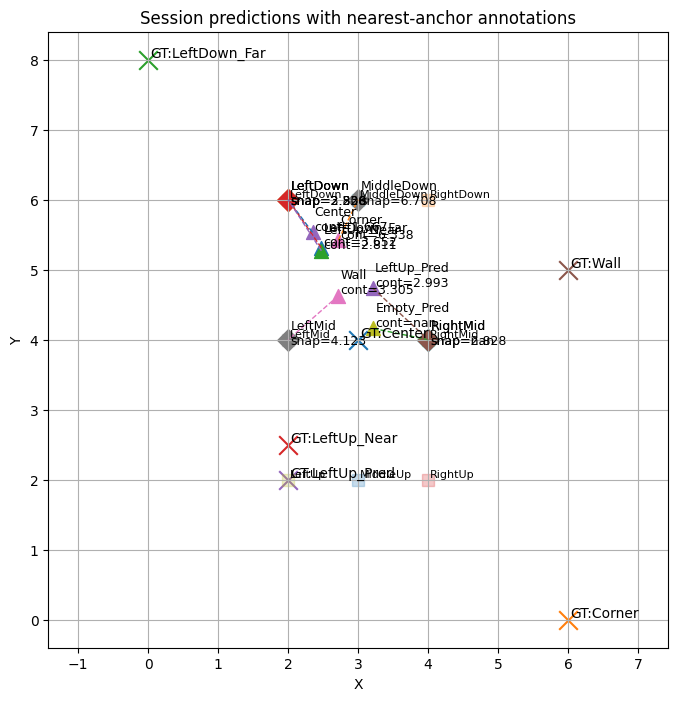

Saved: /home/tonyliao/Location/hybrid_infer_runs/nearest_anchor_plots/session_predictions_global_nearest_anchor.png


In [33]:
plt.figure(figsize=(8, 8))

for _, row in df_sess.iterrows():
    if np.isfinite(row["true_x"]) and np.isfinite(row["true_y"]):
        plt.scatter(row["true_x"], row["true_y"], marker="x", s=180)
        plt.text(row["true_x"] + 0.03, row["true_y"] + 0.03, f"GT:{row['raw_folder_name']}")

for anchor_name, anchor_xy in CLASS_CENTER_MAP.items():
    if anchor_name == "Empty":
        continue
    anchor_xy = np.asarray(anchor_xy, dtype=np.float32)
    plt.scatter(anchor_xy[0], anchor_xy[1], marker="s", s=80, alpha=0.25)
    plt.text(anchor_xy[0] + 0.03, anchor_xy[1] + 0.03, anchor_name, fontsize=8)

for _, row in df_sess.iterrows():
    name = row["raw_folder_name"]

    if row["Pred Empty"] == "Yes":
        if np.isfinite(row["true_x"]) and np.isfinite(row["true_y"]):
            plt.text(
                row["true_x"] + 0.03,
                row["true_y"] - 0.08,
                f"{name}\nPred Empty",
                fontsize=9
            )
        continue

    plt.scatter(row["weighted_x"], row["weighted_y"], s=100, marker="^")
    plt.text(
        row["weighted_x"] + 0.03,
        row["weighted_y"] + 0.03,
        f"{name}\ncont={row['err_weighted']:.3f}",
        fontsize=9
    )

    plt.scatter(row["snap_weighted_x"], row["snap_weighted_y"], s=120, marker="D")
    plt.text(
        row["snap_weighted_x"] + 0.03,
        row["snap_weighted_y"] - 0.06,
        f"{row['snap_weighted_label']}\nsnap={row['err_weighted_snap']:.3f}",
        fontsize=9
    )

    plt.plot(
        [row["weighted_x"], row["snap_weighted_x"]],
        [row["weighted_y"], row["snap_weighted_y"]],
        "--",
        linewidth=1
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Session predictions with nearest-anchor annotations")
plt.grid(True)
plt.axis("equal")

out_path = os.path.join(FIG_DIR, "session_predictions_global_nearest_anchor.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

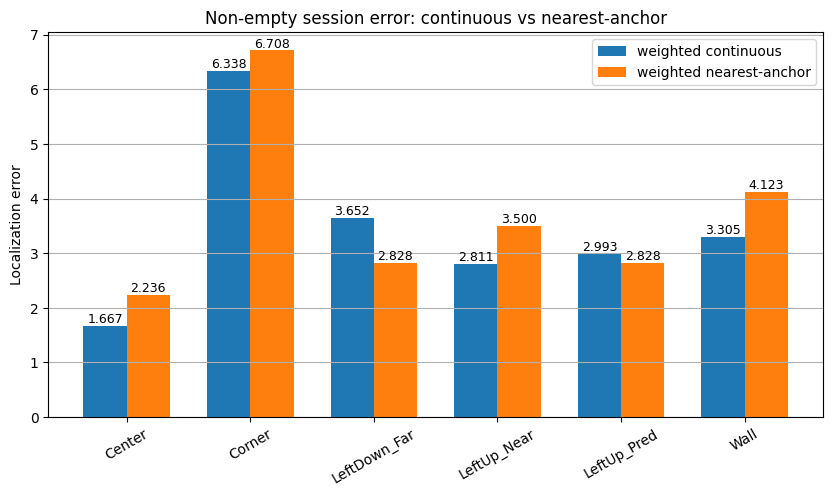

Saved: /home/tonyliao/Location/hybrid_infer_runs/nearest_anchor_plots/session_error_continuous_vs_nearest_anchor.png


In [34]:
mask_loc = (
    (df_sess["has_gt"] == 1) &
    (df_sess["GT Empty"] == "No") &
    (df_sess["Pred Empty"] == "No")
)

err_plot_df = df_sess.loc[mask_loc, ["raw_folder_name", "err_weighted", "err_weighted_snap"]].copy()
err_plot_df = err_plot_df.sort_values("raw_folder_name").reset_index(drop=True)

x = np.arange(len(err_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, err_plot_df["err_weighted"], width, label="weighted continuous")
bars2 = plt.bar(x + width/2, err_plot_df["err_weighted_snap"], width, label="weighted nearest-anchor")

plt.xticks(x, err_plot_df["raw_folder_name"], rotation=30)
plt.ylabel("Localization error")
plt.title("Non-empty session error: continuous vs nearest-anchor")
plt.legend()
plt.grid(True, axis="y")

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

out_path = os.path.join(FIG_DIR, "session_error_continuous_vs_nearest_anchor.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

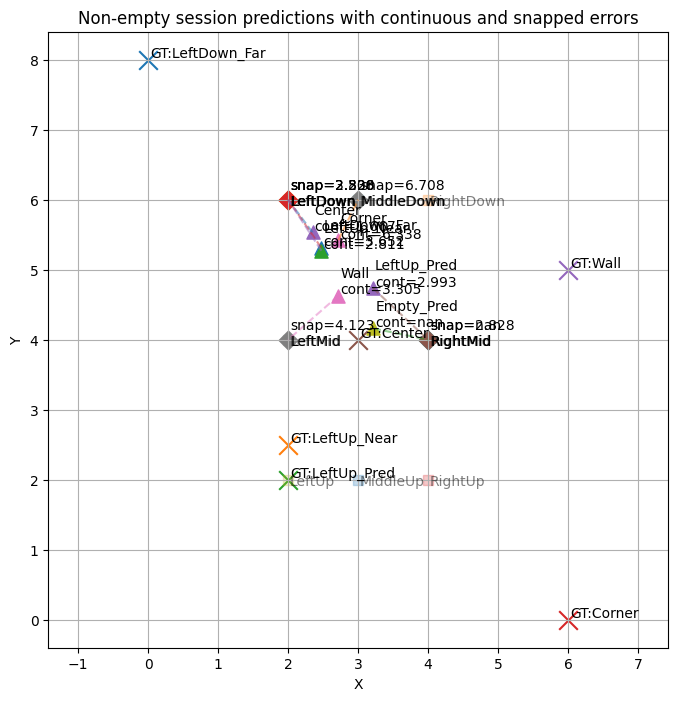

Saved: /home/tonyliao/Location/hybrid_infer_runs/nearest_anchor_plots/session_predictions_with_snapped_annotations.png


In [35]:
plt.figure(figsize=(8, 8))

for name, xy in UNSEEN_GT_COORDS.items():
    if str(name).lower().startswith("empty"):
        continue
    plt.scatter(xy[0], xy[1], marker="x", s=180)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, f"GT:{name}")

for name, xy in CLASS_CENTER_MAP.items():
    if name == "Empty":
        continue
    plt.scatter(xy[0], xy[1], marker="s", s=60, alpha=0.25)
    plt.text(xy[0] + 0.02, xy[1] - 0.08, name, alpha=0.5)

for _, row in df_sess.iterrows():
    name = row["raw_folder_name"]

    if row["Pred Empty"] == "Yes":
        continue

    plt.scatter(row["weighted_x"], row["weighted_y"], s=90, marker="^")
    plt.text(
        row["weighted_x"] + 0.03,
        row["weighted_y"] + 0.03,
        f"{name}\ncont={row['err_weighted']:.3f}"
    )

    plt.scatter(row["snap_weighted_x"], row["snap_weighted_y"], s=90, marker="D")
    plt.text(
        row["snap_weighted_x"] + 0.03,
        row["snap_weighted_y"] - 0.08,
        f"snap={row['err_weighted_snap']:.3f}\n{row['snap_weighted_label']}"
    )

    plt.plot(
        [row["weighted_x"], row["snap_weighted_x"]],
        [row["weighted_y"], row["snap_weighted_y"]],
        linestyle="--",
        alpha=0.5
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Non-empty session predictions with continuous and snapped errors")
plt.grid(True)
plt.axis("equal")

out_path = os.path.join(FIG_DIR, "session_predictions_with_snapped_annotations.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()
#Restart the kernel to free memory
import IPython
app = IPython.get_ipython()
app.kernel.do_shutdown(True)  # True = restart, False = shutdown

{'status': 'ok', 'restart': True}

: 